# SmartInsight (PyTorch) — End-to-End Notebook
This notebook builds an end-to-end analytics pipeline:
1) Load data  
2) EDA (understand data + quality)  
3) Preprocess (make data numeric + scaled)  
4) Train a PyTorch neural network  
5) Evaluate performance  
6) Save + load model (.pt)  
7) Run inference (predict on new data)

In [1]:
!pip -q install pandas numpy torch scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

## Part 1 — Upload your dataset
Upload `dataset.csv` to Colab:
- Left sidebar → Files → Upload → choose `dataset.csv`

Then set `DATA_PATH` below.

In [2]:
DATA_PATH = "/content/dataset.csv"  # change if needed
TARGET = "churn"

df = pd.read_csv(DATA_PATH, parse_dates=["signup_date"])
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset.csv'

In [ ]:
print("Shape (rows, cols):", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values (%):")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct)

print("\nTarget distribution:")
display(df[TARGET].value_counts())
display(df[TARGET].value_counts(normalize=True))

Shape (rows, cols): (1200, 10)

Data types:
customer_id                 int64
age                       float64
tenure_months               int64
monthly_charges           float64
support_calls               int64
contract_type              object
payment_method             object
region                     object
signup_date        datetime64[ns]
churn                       int64
dtype: object

Missing values (%):


,0
age,5.0
monthly_charges,5.0
payment_method,5.0
customer_id,0.0
support_calls,0.0
tenure_months,0.0
contract_type,0.0
region,0.0
signup_date,0.0
churn,0.0



Target distribution:


,count
churn,
0,905
1,295


,proportion
churn,
0,0.754167
1,0.245833


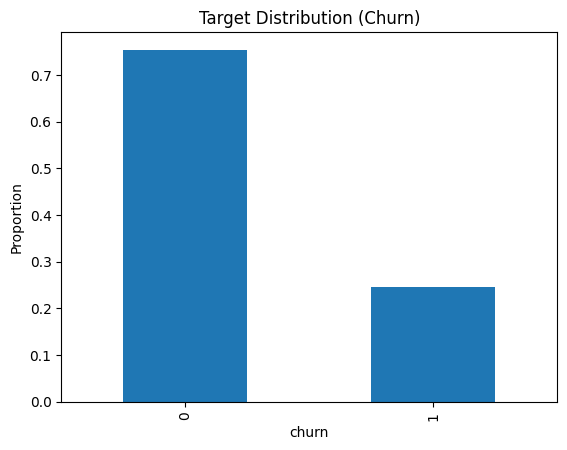

,customer_id,age,tenure_months,monthly_charges,support_calls,signup_date,churn
count,1200.000000,1140.000000,1200.000000,1140.000000,1200.000000,1200,1200.000000
mean,600.500000,43.397368,34.954167,70.308763,1.977500,2020-10-11 09:06:00,0.245833
min,1.000000,18.000000,1.000000,20.020000,0.000000,2018-01-02 00:00:00,0.000000
25%,300.750000,30.000000,17.000000,44.662500,1.000000,2019-06-22 06:00:00,0.000000
50%,600.500000,43.000000,35.000000,71.890000,2.000000,2020-10-25 12:00:00,0.000000
75%,900.250000,56.000000,52.000000,95.767500,3.000000,2022-01-31 06:00:00,0.000000
max,1200.000000,69.000000,71.000000,119.970000,9.000000,2023-06-23 00:00:00,1.000000
std,346.554469,15.047568,20.288258,29.174447,1.439463,NaN,0.430760


In [ ]:
# Target bar plot
plt.figure()
df[TARGET].value_counts(normalize=True).plot(kind="bar")
plt.title("Target Distribution (Churn)")
plt.ylabel("Proportion")
plt.show()

# Numeric summary
display(df.describe())

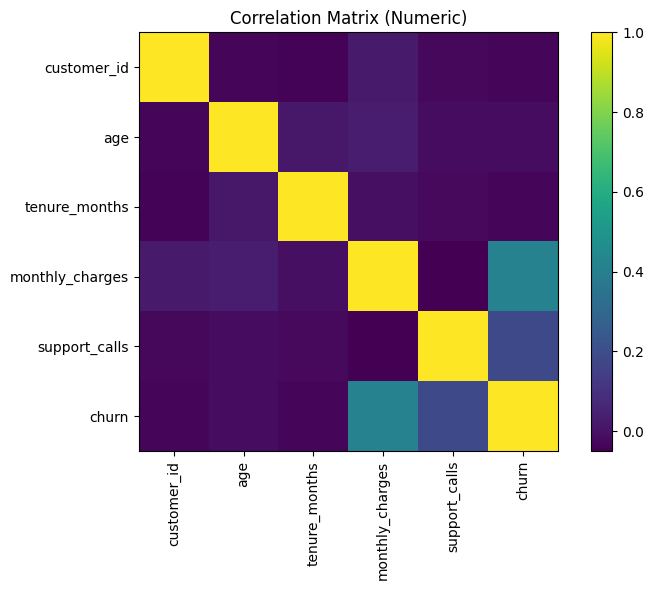

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.title("Correlation Matrix (Numeric)")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

## Part 2 — Preprocessing (make data usable for a neural network)

PyTorch neural networks only accept numeric tensors.

So we will:
1) Separate features `X` and target `y`
2) Convert categorical columns (text) to numeric using one-hot encoding
3) Fill missing values
4) Split train/test
5) Scale features (important for neural networks)

In [ ]:
# Separate features and target
X = df.drop(columns=[TARGET, "customer_id"])
y = df[TARGET].values  # 0/1

# One-hot encode text/categorical columns
X = pd.get_dummies(X, drop_first=True)

# Fill missing numeric values with median
X = X.fillna(X.median(numeric_only=True))

# Save feature names (important for future inference consistency)
feature_names = X.columns.tolist()

print("Total features after one-hot:", len(feature_names))
print("First 10 feature names:", feature_names[:10])

Total features after one-hot: 13
First 10 feature names: ['age', 'tenure_months', 'monthly_charges', 'support_calls', 'signup_date', 'contract_type_One year', 'contract_type_Two year', 'payment_method_Credit Card', 'payment_method_Debit Card', 'payment_method_Electronic Check']


In [ ]:
if 'signup_date' in X.columns:
    X_for_split = X.drop(columns=['signup_date'])
else:
    X_for_split = X

# Update feature_names to reflect the dropped column if it was present
feature_names = X_for_split.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_for_split.values, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

input_dim = X_train.shape[1]
print("Input dimension:", input_dim)

Input dimension: 12


## Part 3 — Convert to PyTorch format
- Tensors = PyTorch data type
- DataLoader = batches data during training (faster + standard)

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

len(train_loader), len(test_loader)

(15, 4)

## Part 4 — Define a PyTorch Neural Network (Model)

- Input: `input_dim` features
- Output: 1 value (logit)
- We convert logits to probabilities using sigmoid during evaluation/inference.

In [ ]:
class ChurnNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # binary output (logit)
        )

    def forward(self, x):
        return self.net(x)

## Part 5 — Training loop (learning)

For each batch:
1) Model predicts logits
2) Compute loss (how wrong)
3) Backpropagation (compute gradients)
4) Optimizer updates weights
Repeat for multiple epochs

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = ChurnNet(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()  # best for binary classification with logits
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_loss:.4f}")

Using device: cpu
Epoch 1/15 | loss=9.5015
Epoch 2/15 | loss=8.2542
Epoch 3/15 | loss=7.5348
Epoch 4/15 | loss=6.9237
Epoch 5/15 | loss=6.4079
Epoch 6/15 | loss=5.7802
Epoch 7/15 | loss=5.2586
Epoch 8/15 | loss=4.8127
Epoch 9/15 | loss=4.4333
Epoch 10/15 | loss=4.1518
Epoch 11/15 | loss=3.9751
Epoch 12/15 | loss=4.0079
Epoch 13/15 | loss=3.7700
Epoch 14/15 | loss=3.8774
Epoch 15/15 | loss=3.6623


## Part 6 — Evaluation

We compute:
- Accuracy
- F1 score
- ROC-AUC

We also print a confusion matrix and classification report.

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device)).cpu().numpy()

# Convert logits -> probabilities
probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int)

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)
auc = roc_auc_score(y_test, probs)

print("Accuracy:", acc)
print("F1:", f1)
print("ROC-AUC:", auc)

print("\nClassification report:")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.9083333333333333
F1: 0.8225806451612904
ROC-AUC: 0.9629178762056372

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       181
           1       0.78      0.86      0.82        59

    accuracy                           0.91       240
   macro avg       0.87      0.89      0.88       240
weighted avg       0.91      0.91      0.91       240


Confusion Matrix:
 [[167  14]
 [  8  51]]


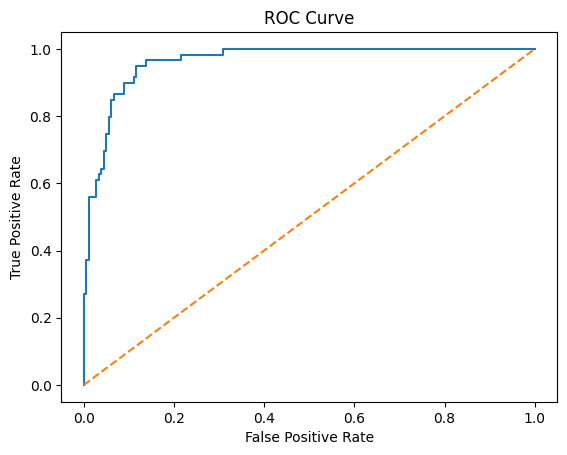

In [ ]:
# Basic ROC curve plot (no sklearn display object needed)
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## Part 7 — Save everything

Important:
- The PyTorch model weights alone are not enough.
- You must also save:
  - input_dim
  - scaler
  - feature_names (so new data matches training columns)

We save:
- `churn_model.pt` (PyTorch weights)
- `preprocess.pkl` (scaler + feature_names)

In [ ]:
import joblib

# Save PyTorch checkpoint
torch.save({
    "model_state": model.state_dict(),
    "input_dim": input_dim
}, "/content/churn_model.pt")

# Save preprocessing objects
joblib.dump({
    "scaler": scaler,
    "feature_names": feature_names
}, "/content/preprocess.pkl")

print("Saved: /content/churn_model.pt and /content/preprocess.pkl")

Saved: /content/churn_model.pt and /content/preprocess.pkl


## Part 8 — Load and predict on NEW data

We will:
1) Create one new customer row (dictionary)
2) Convert to DataFrame
3) One-hot encode with same feature columns
4) Scale using saved scaler
5) Predict probability using loaded PyTorch model

In [ ]:
# Load preprocess objects
prep = joblib.load("/content/preprocess.pkl")
scaler_loaded = prep["scaler"]
feature_names_loaded = prep["feature_names"]

# Load model checkpoint
ckpt = torch.load("/content/churn_model.pt", map_location=device)

loaded_model = ChurnNet(ckpt["input_dim"]).to(device)
loaded_model.load_state_dict(ckpt["model_state"])
loaded_model.eval()

# Example new customer (must match original raw column names BEFORE one-hot)
new_customer = {
    "age": 45,
    "tenure_months": 12,
    "monthly_charges": 95,
    "support_calls": 4,
    "contract_type": "Month-to-month",
    "payment_method": "Credit Card",
    "region": "North",
    "signup_date": "2023-01-01"
}

# Convert to DataFrame
new_df = pd.DataFrame([new_customer])
new_df["signup_date"] = pd.to_datetime(new_df["signup_date"])

# One-hot encode
new_X = pd.get_dummies(new_df, drop_first=True)

# Align columns to training feature set (missing columns -> 0)
for col in feature_names_loaded:
    if col not in new_X.columns:
        new_X[col] = 0

# Extra columns not seen during training -> drop them
new_X = new_X[feature_names_loaded]

# Fill missing + scale
new_X = new_X.fillna(new_X.median(numeric_only=True))
new_X_scaled = scaler_loaded.transform(new_X.values)

# Predict
new_t = torch.tensor(new_X_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    logit = loaded_model(new_t)
    prob = torch.sigmoid(logit).item()

print("Predicted churn probability:", prob)
print("Predicted class (>=0.5 churn):", int(prob >= 0.5))

Predicted churn probability: 0.8896445631980896
Predicted class (>=0.5 churn): 1


# Done
You now have an end-to-end PyTorch pipeline:
- EDA
- Preprocessing
- Training
- Evaluation
- Save/load
- Inference

Next upgrades (SmartInsight features):
- Explainability (Captum)
- Auto insight rules (segments, anomalies)
- LLM summary (Hugging Face) based on metrics + insights

# Part 9 — Explainability (PyTorch + Captum)

Now that our model can predict churn, the next question is:

**Why did the model predict that?**

Explainability helps us:
- Build trust (not a black box)
- Communicate insights to non-technical people
- Identify what features drive churn most

We will use **Captum**, the official PyTorch library for interpretability.

## 9.1 Import Integrated Gradients

We will use **Integrated Gradients (IG)**:
- A popular method to measure **feature contributions**
- It compares the model output on a baseline input vs the real input
- Result: each feature gets an “attribution score”

**Interpretation:**
- Positive attribution → pushes prediction UP (more churn)
- Negative attribution → pushes prediction DOWN (less churn)
- Larger magnitude → stronger influence

In [ ]:
!pip install captum

from captum.attr import IntegratedGradients
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 34.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have nu

## 9.2 Put the model in evaluation mode

This is important because training mode uses things like dropout,
which makes explanations unstable.

So we always run explainability with:
- `model.eval()`
- `torch.no_grad()` when needed

In [ ]:
model.eval()

ChurnNet(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 9.3 Choose a baseline input

Integrated Gradients needs a **baseline** (a neutral reference).

Since we scaled our data, **0** represents the “average” value for each feature,
so a common baseline is an all-zero vector.

This baseline means:
> “Compare the prediction for this customer against an average/neutral customer.”

In [ ]:
baseline_all = torch.zeros_like(X_test_t)  # same shape as X_test_t

## 9.4 Create the Integrated Gradients explainer

We pass the model to Captum.
Captum will compute how each input feature affects the model’s output.

In [ ]:
ig = IntegratedGradients(model)

## 9.5 Local explanation (one customer)

A **local explanation** answers:
> “Why did the model predict churn for THIS specific customer?”

We will:
1) Choose one test example (by index)
2) Compute attributions with Integrated Gradients
3) Show the top 10 most influential features for that prediction

In [ ]:
# Pick one customer from the test set
idx = 0

input_sample = X_test_t[idx].unsqueeze(0).to(device)  # shape: (1, num_features)
baseline = baseline_all[idx].unsqueeze(0).to(device)

# Compute attributions
attributions, delta = ig.attribute(
    inputs=input_sample,
    baselines=baseline,
    return_convergence_delta=True
)

# Convert to 1D array
attrs = attributions.detach().cpu().numpy().flatten()

## 9.6 View top feature contributions (local)

We build a table:
- `feature`: feature name
- `attribution`: contribution score

We sort by absolute value so we see the strongest drivers (positive or negative).

In [ ]:
local_df = pd.DataFrame({
    "feature": feature_names,
    "attribution": attrs
})

local_df["abs_attr"] = local_df["attribution"].abs()
local_df = local_df.sort_values("abs_attr", ascending=False)

local_df.head(10)

,feature,attribution,abs_attr
3,support_calls,-2.159914,2.159914
4,contract_type_One year,1.511525,1.511525
5,contract_type_Two year,0.701133,0.701133
8,payment_method_Electronic Check,-0.422304,0.422304
1,tenure_months,-0.352927,0.352927
2,monthly_charges,0.286843,0.286843
10,region_South,-0.197738,0.197738
9,region_North,-0.170936,0.170936
6,payment_method_Credit Card,-0.168518,0.168518
7,payment_method_Debit Card,-0.094570,0.094570


## 9.7 Local explanation plot (top 10)

This plot makes it easier to understand:
- Bars to the right (positive) increase churn prediction
- Bars to the left (negative) decrease churn prediction

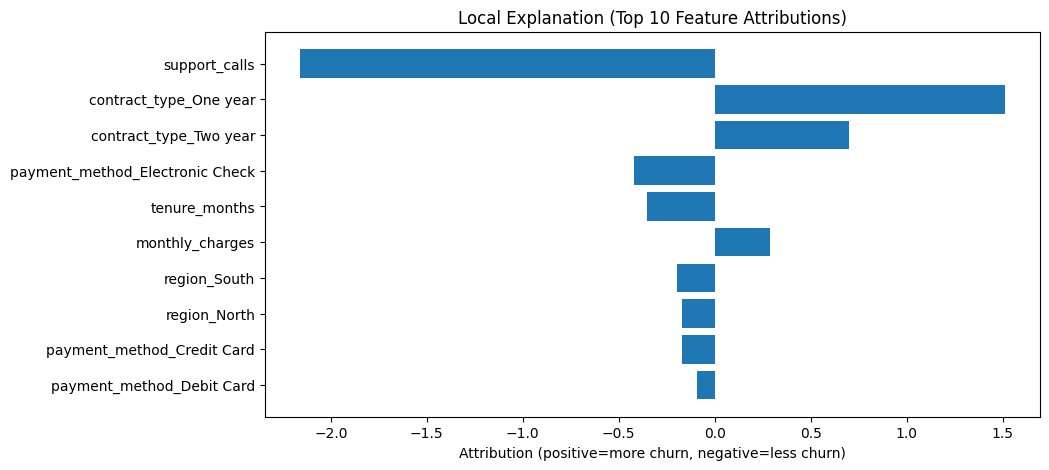

In [ ]:
top_k = 10
plot_df = local_df.head(top_k).copy()

plt.figure(figsize=(10, 5))
plt.barh(plot_df["feature"][::-1], plot_df["attribution"][::-1])
plt.title("Local Explanation (Top 10 Feature Attributions)")
plt.xlabel("Attribution (positive=more churn, negative=less churn)")
plt.show()

## 9.8 Global explanation (overall feature importance)

A **global explanation** answers:
> “Overall, across many customers, which features matter most?”

We will:
1) Compute attributions for many test samples
2) Take the **mean absolute attribution** per feature
3) Rank features by importance

Mean absolute attribution = “on average, how strong is this feature’s effect?”

In [ ]:
N = 200  # number of test samples to explain (increase for more stable results)

inputs = X_test_t[:N].to(device)
baselines = torch.zeros_like(inputs)

attrs_batch, _ = ig.attribute(inputs, baselines, return_convergence_delta=True)

# Mean absolute attribution per feature
global_importance = attrs_batch.abs().mean(dim=0).detach().cpu().numpy()

global_df = pd.DataFrame({
    "feature": feature_names,
    "importance": global_importance
}).sort_values("importance", ascending=False)

global_df.head(10)

,feature,importance
4,contract_type_One year,2.211850
2,monthly_charges,1.890263
5,contract_type_Two year,1.295493
3,support_calls,1.053094
1,tenure_months,0.223751
0,age,0.188496
9,region_North,0.157346
7,payment_method_Debit Card,0.151361
8,payment_method_Electronic Check,0.141926
6,payment_method_Credit Card,0.135525


## 9.9 Global feature importance plot

This shows the top features driving churn in your dataset,
which is usually what you present to stakeholders.

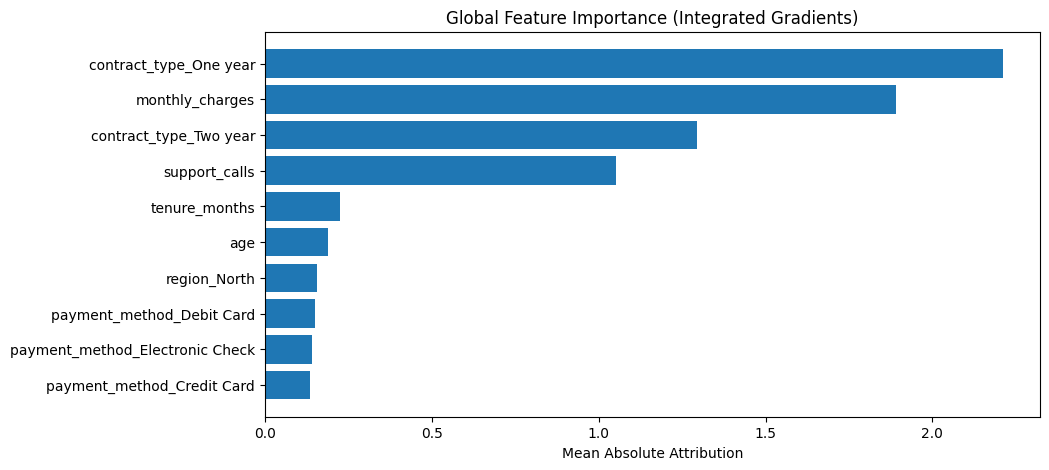

In [ ]:
top_k = 10
plt.figure(figsize=(10, 5))
plt.barh(global_df["feature"][:top_k][::-1], global_df["importance"][:top_k][::-1])
plt.title("Global Feature Importance (Integrated Gradients)")
plt.xlabel("Mean Absolute Attribution")
plt.show()

## 9.10 How to talk about results (business language)

After you run this, you can write statements like:

- “The most important churn drivers are: X, Y, Z”
- “High values of feature X increase churn risk”
- “Feature Y tends to reduce churn risk”

This turns your model into decision support, not just predictions.

# Part 10 — Automated Insights + Executive Summary (LLM-ready)

Now we move from "model outputs" to "business insights".

We will:
1) Generate **rule-based insights** from the dataset (no hallucinations)
2) Build a structured JSON called `insight_payload`
3) Create a human-readable **executive summary** (template-based)
4) (Optional) Send the payload to an LLM later for a polished narrative

Why rule-based first?
- It guarantees the facts are correct
- The LLM can then *rephrase*, not invent

## 10.1 Quick business metrics from the dataset

We compute:
- churn rate overall
- churn rate by contract type
- churn rate by region
- churn rate by payment method

These are useful for stakeholder-level insights.

In [ ]:
import pandas as pd
import numpy as np
import json

TARGET = "churn"  # keep consistent

def churn_rate(series):
    return float(series.mean())

overall_churn = churn_rate(df[TARGET])

by_contract = (
    df.groupby("contract_type")[TARGET]
      .mean()
      .sort_values(ascending=False)
      .to_dict()
)

by_region = (
    df.groupby("region")[TARGET]
      .mean()
      .sort_values(ascending=False)
      .to_dict()
)

by_payment = (
    df.groupby("payment_method")[TARGET]
      .mean()
      .sort_values(ascending=False)
      .to_dict()
)

overall_churn, by_contract

(0.24583333333333332,
 {'Month-to-month': 0.41251778093883357,
  'Two year': 0.011049723756906077,
  'One year': 0.00949367088607595})

## 10.2 Identify "at-risk segments"

A segment is "at-risk" if its churn rate is significantly higher than overall.

We will flag:
- Any segment with churn > overall churn + threshold

You can tune the threshold. We'll start with +10 percentage points.

In [ ]:
THRESHOLD = 0.10  # 10 percentage points above overall churn

def find_risky_segments(group_dict, overall, threshold=0.10):
    risky = []
    for k, v in group_dict.items():
        if v >= overall + threshold:
            risky.append({"segment": k, "churn_rate": float(v)})
    # sort by churn rate descending
    risky.sort(key=lambda x: x["churn_rate"], reverse=True)
    return risky

risky_contracts = find_risky_segments(by_contract, overall_churn, THRESHOLD)
risky_regions = find_risky_segments(by_region, overall_churn, THRESHOLD)
risky_payments = find_risky_segments(by_payment, overall_churn, THRESHOLD)

risky_contracts[:3], risky_regions[:3]

([{'segment': 'Month-to-month', 'churn_rate': 0.41251778093883357}], [])

## 10.3 Convert explainability into "top drivers"

We already have `global_df` from Captum (feature importance).
We will extract the top 10 features and treat them as "drivers".

This becomes a core part of the final report.

In [ ]:
# Ensure global_df exists from Part 9
top_drivers = global_df.head(10).to_dict(orient="records")
top_drivers

[{'feature': 'contract_type_One year', 'importance': 2.211850166320801},
 {'feature': 'monthly_charges', 'importance': 1.8902627229690552},
 {'feature': 'contract_type_Two year', 'importance': 1.2954931259155273},
 {'feature': 'support_calls', 'importance': 1.053093671798706},
 {'feature': 'tenure_months', 'importance': 0.22375079989433289},
 {'feature': 'age', 'importance': 0.18849556148052216},
 {'feature': 'region_North', 'importance': 0.1573462337255478},
 {'feature': 'payment_method_Debit Card', 'importance': 0.151361346244812},
 {'feature': 'payment_method_Electronic Check',
  'importance': 0.14192627370357513},
 {'feature': 'payment_method_Credit Card', 'importance': 0.13552503287792206}]

## 10.4 Create structured insights (facts + recommended actions)

We create an "insight list" that is:
- easy to show on a dashboard
- easy to feed to an LLM later
- guaranteed fact-based (computed from data)

In [ ]:
insights = []

# Insight 1: Overall churn
insights.append({
    "type": "kpi",
    "title": "Overall churn rate",
    "value": overall_churn,
    "interpretation": f"About {overall_churn:.1%} of customers churn in this dataset."
})

# Insight 2: Highest churn contract type
if by_contract:
    worst_contract = max(by_contract, key=by_contract.get)
    insights.append({
        "type": "segment",
        "title": "Highest churn by contract type",
        "segment": worst_contract,
        "value": float(by_contract[worst_contract]),
        "recommendations": [
            "Offer incentives to move customers from month-to-month to longer contracts",
            "Improve onboarding and early engagement for short-term contract customers"
        ]
    })

# Insight 3: Risky contracts list
if risky_contracts:
    insights.append({
        "type": "risk",
        "title": "At-risk contract segments",
        "details": risky_contracts,
        "recommendations": [
            "Create targeted retention campaigns for the highest-risk contract group",
            "Review pricing and customer support experience for these segments"
        ]
    })

# Insight 4: Top drivers from explainability
insights.append({
    "type": "explainability",
    "title": "Top churn drivers (model explainability)",
    "details": top_drivers,
    "recommendations": [
        "Monitor the top drivers and build alerts when customers exhibit high-risk patterns",
        "Use driver insights to prioritize product and support improvements"
    ]
})

insights[:2]

[{'type': 'kpi',
  'title': 'Overall churn rate',
  'value': 0.24583333333333332,
  'interpretation': 'About 24.6% of customers churn in this dataset.'},
 {'type': 'segment',
  'title': 'Highest churn by contract type',
  'segment': 'Month-to-month',
  'value': 0.41251778093883357,
  'recommendations': ['Offer incentives to move customers from month-to-month to longer contracts',
   'Improve onboarding and early engagement for short-term contract customers']}]

## 10.5 Build a single JSON payload (LLM-ready)

This payload contains:
- model metrics
- segment churn breakdown
- top drivers from explainability
- rule-based insights

An LLM can then generate a polished report from this payload
without inventing facts.

In [ ]:
# Use metrics if you computed them earlier (acc, f1, auc). If not, set to None.
try:
    metrics = {"accuracy": float(acc), "f1": float(f1), "roc_auc": float(auc)}
except NameError:
    metrics = {"accuracy": None, "f1": None, "roc_auc": None}

insight_payload = {
    "dataset": {
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "target": TARGET,
        "overall_churn_rate": float(overall_churn)
    },
    "model_metrics": metrics,
    "segment_churn": {
        "by_contract_type": by_contract,
        "by_region": by_region,
        "by_payment_method": by_payment
    },
    "risky_segments": {
        "contracts": risky_contracts,
        "regions": risky_regions,
        "payments": risky_payments
    },
    "top_drivers": top_drivers,
    "insights": insights
}

# Preview JSON (short)
print(json.dumps(insight_payload, indent=2)[:1200])

{
  "dataset": {
    "rows": 1200,
    "columns": 10,
    "target": "churn",
    "overall_churn_rate": 0.24583333333333332
  },
  "model_metrics": {
    "accuracy": 0.9083333333333333,
    "f1": 0.8225806451612904,
    "roc_auc": 0.9629178762056372
  },
  "segment_churn": {
    "by_contract_type": {
      "Month-to-month": 0.41251778093883357,
      "Two year": 0.011049723756906077,
      "One year": 0.00949367088607595
    },
    "by_region": {
      "North": 0.25732899022801303,
      "South": 0.24535315985130113,
      "East": 0.2408026755852843,
      "West": 0.24
    },
    "by_payment_method": {
      "Bank Transfer": 0.25496688741721857,
      "Debit Card": 0.25,
      "Electronic Check": 0.23636363636363636,
      "Credit Card": 0.2332155477031802
    }
  },
  "risky_segments": {
    "contracts": [
      {
        "segment": "Month-to-month",
        "churn_rate": 0.41251778093883357
      }
    ],
    "regions": [],
    "payments": []
  },
  "top_drivers": [
    {
      "featu

## 10.6 Generate an executive summary (template-based)

This is NOT an LLM yet.
It is a safe, deterministic summary based on the payload.

Later, you can pass the payload to Hugging Face to produce
a more polished narrative.

In [ ]:
def executive_summary(payload):
    rows = payload["dataset"]["rows"]
    churn = payload["dataset"]["overall_churn_rate"]
    m = payload["model_metrics"]
    top = payload["top_drivers"][:5]

    lines = []
    lines.append(f"Executive Summary")
    lines.append(f"- Dataset: {rows} customers. Overall churn rate: {churn:.1%}.")
    if m["accuracy"] is not None:
        lines.append(f"- Model performance: Accuracy={m['accuracy']:.3f}, F1={m['f1']:.3f}, ROC-AUC={m['roc_auc']:.3f}.")
    else:
        lines.append(f"- Model performance: (metrics not found in notebook state).")
    lines.append("- Top churn drivers (from explainability):")
    for d in top:
        lines.append(f"  • {d['feature']} (importance={d['importance']:.4f})")

    # Risky segment highlight
    risky_contracts = payload["risky_segments"]["contracts"]
    if risky_contracts:
        lines.append("- At-risk segments:")
        for seg in risky_contracts[:3]:
            lines.append(f"  • Contract={seg['segment']} (churn={seg['churn_rate']:.1%})")

    lines.append("- Recommended actions:")
    lines.append("  • Target retention campaigns for at-risk segments.")
    lines.append("  • Use driver insights to improve pricing/support/product experience.")
    return "\n".join(lines)

summary_text = executive_summary(insight_payload)
print(summary_text)

Executive Summary
- Dataset: 1200 customers. Overall churn rate: 24.6%.
- Model performance: Accuracy=0.908, F1=0.823, ROC-AUC=0.963.
- Top churn drivers (from explainability):
  • contract_type_One year (importance=2.2119)
  • monthly_charges (importance=1.8903)
  • contract_type_Two year (importance=1.2955)
  • support_calls (importance=1.0531)
  • tenure_months (importance=0.2238)
- At-risk segments:
  • Contract=Month-to-month (churn=41.3%)
- Recommended actions:
  • Target retention campaigns for at-risk segments.
  • Use driver insights to improve pricing/support/product experience.


## 10.7 Save results (JSON + summary)

This creates artifacts you can upload to GitHub:
- `insight_payload.json` (facts + drivers + metrics)
- `executive_summary.txt` (human-readable)

In [ ]:
with open("/content/insight_payload.json", "w") as f:
    json.dump(insight_payload, f, indent=2)

with open("/content/executive_summary.txt", "w") as f:
    f.write(summary_text)

print("Saved:")
print("- /content/insight_payload.json")
print("- /content/executive_summary.txt")

Saved:
- /content/insight_payload.json
- /content/executive_summary.txt


# How to use (not run) a JSON file

A `.json` file is just a structured text file that stores data.
It cannot be executed like a `.py` file.

You typically use a JSON file to:
- inspect results
- load data into Python
- send data to an API or an LLM
- display insights in a dashboard

## Example: `insight_payload.json`

This file contains:
- dataset info
- model metrics
- risky segments
- explainability results
- business insights

We will now LOAD it into Python.

In [ ]:
import json

# Path to the JSON file (Colab)
JSON_PATH = "/content/insight_payload.json"

# Load JSON into a Python dictionary
with open(JSON_PATH, "r") as f:
    insight_payload = json.load(f)

type(insight_payload)

dict

## Inspect the JSON contents

You can now explore it like any Python dictionary.

In [ ]:
# Pretty print the full JSON (careful: long output)
print(json.dumps(insight_payload, indent=2)[:1500])

{
  "dataset": {
    "rows": 1200,
    "columns": 10,
    "target": "churn",
    "overall_churn_rate": 0.24583333333333332
  },
  "model_metrics": {
    "accuracy": 0.9083333333333333,
    "f1": 0.8225806451612904,
    "roc_auc": 0.9629178762056372
  },
  "segment_churn": {
    "by_contract_type": {
      "Month-to-month": 0.41251778093883357,
      "Two year": 0.011049723756906077,
      "One year": 0.00949367088607595
    },
    "by_region": {
      "North": 0.25732899022801303,
      "South": 0.24535315985130113,
      "East": 0.2408026755852843,
      "West": 0.24
    },
    "by_payment_method": {
      "Bank Transfer": 0.25496688741721857,
      "Debit Card": 0.25,
      "Electronic Check": 0.23636363636363636,
      "Credit Card": 0.2332155477031802
    }
  },
  "risky_segments": {
    "contracts": [
      {
        "segment": "Month-to-month",
        "churn_rate": 0.41251778093883357
      }
    ],
    "regions": [],
    "payments": []
  },
  "top_drivers": [
    {
      "featu

## Access specific parts of the JSON

This is usually what you do in real projects:
you extract only what you need.

In [ ]:
# Dataset info
insight_payload["dataset"]

{'rows': 1200,
 'columns': 10,
 'target': 'churn',
 'overall_churn_rate': 0.24583333333333332}

In [ ]:
# Model metrics
insight_payload["model_metrics"]

{'accuracy': 0.9083333333333333,
 'f1': 0.8225806451612904,
 'roc_auc': 0.9629178762056372}

In [ ]:
# Top churn drivers
insight_payload["top_drivers"][:5]

[{'feature': 'contract_type_One year', 'importance': 2.211850166320801},
 {'feature': 'monthly_charges', 'importance': 1.8902627229690552},
 {'feature': 'contract_type_Two year', 'importance': 1.2954931259155273},
 {'feature': 'support_calls', 'importance': 1.053093671798706},
 {'feature': 'tenure_months', 'importance': 0.22375079989433289}]

In [ ]:
# Risky contract segments
insight_payload["risky_segments"]["contracts"]

[{'segment': 'Month-to-month', 'churn_rate': 0.41251778093883357}]

## Turn JSON into readable text (manual, no LLM)

This shows how JSON becomes human insight.

In [ ]:
for insight in insight_payload["insights"]:
    print(f"- {insight['title']}")

- Overall churn rate
- Highest churn by contract type
- At-risk contract segments
- Top churn drivers (model explainability)


## When people say "run the JSON", what they REALLY mean

They usually mean one of these:

1) Load it into Python (what we just did)
2) Send it to an LLM (ChatGPT, Hugging Face, etc.)
3) Show it in a dashboard (Streamlit, web app)
4) Use it as input to another program

JSON is INPUT, not EXECUTION.

## Mental model (very important)

Think of it like this:

- `.py` → instructions (code)
- `.pt` → trained model (weights)
- `.json` → facts / results / data

You run `.py`
You load `.pt`
You read `.json`

## Example: Using JSON with an LLM (next step)

In the next step, we will:
- load `insight_payload.json`
- send it to a Hugging Face / ChatGPT model
- ask the LLM to write a polished executive report

The LLM does NOT invent facts — it only rewrites the JSON.

# Part 11 — LLM Executive Report

We already have:
- A trained PyTorch model
- Explainability results
- Business insights stored in `insight_payload.json`

Now we use a **Large Language Model (LLM)** to:
- Read the JSON
- Rewrite it into a **clear executive report**
- Keep facts unchanged
- Improve clarity and language

Important rule:
 The LLM does NOT invent facts.
 It only rewrites what is already in the JSON.

## 11.1 Load the insight payload (JSON)

The JSON is the **source of truth**.
Everything the LLM writes must come from this data.

In [ ]:
import json

JSON_PATH = "/content/insight_payload.json"

with open(JSON_PATH, "r") as f:
    insight_payload = json.load(f)

print("Keys in payload:", insight_payload.keys())

Keys in payload: dict_keys(['dataset', 'model_metrics', 'segment_churn', 'risky_segments', 'top_drivers', 'insights'])


## 11.2 Build the LLM prompt

A **prompt** is instructions + data.

Good prompt rules:
- Be explicit
- Tell the LLM its role
- Tell it NOT to invent information
- Give it structured input (our JSON)

In [ ]:
def build_prompt(payload):
    return f"""
You are a senior data analyst writing a report for non-technical executives.

Rules:
- Use ONLY the information provided below.
- Do NOT invent numbers or facts.
- If something is missing, say "Not available".
- Be clear, concise, and business-focused.

Write an executive report with these sections:
1. Overview
2. Model Performance
3. Key Churn Drivers
4. At-Risk Segments
5. Recommendations
6. Limitations

DATA (JSON):
{json.dumps(payload, indent=2)}
"""

## OPTION 1 — Simple LLM (Template-based, no API)

This option is:
- Safe
- Offline
- Deterministic
- Good for learning

It simulates what an LLM would do.

In [ ]:
def simple_llm_report(payload):
    lines = []

    ds = payload["dataset"]
    metrics = payload["model_metrics"]
    drivers = payload["top_drivers"][:5]
    risky_contracts = payload["risky_segments"]["contracts"]

    lines.append("# Executive Report\n")

    lines.append("## 1. Overview")
    lines.append(
        f"The analysis was conducted on {ds['rows']} customers. "
        f"The overall churn rate is {ds['overall_churn_rate']:.1%}."
    )

    lines.append("\n## 2. Model Performance")
    if metrics["accuracy"] is not None:
        lines.append(
            f"The predictive model achieved an accuracy of {metrics['accuracy']:.3f}, "
            f"an F1 score of {metrics['f1']:.3f}, and a ROC-AUC of {metrics['roc_auc']:.3f}."
        )
    else:
        lines.append("Model performance metrics were not available.")

    lines.append("\n## 3. Key Churn Drivers")
    for d in drivers:
        lines.append(f"- {d['feature']} (importance score: {d['importance']:.4f})")

    lines.append("\n## 4. At-Risk Segments")
    if risky_contracts:
        for seg in risky_contracts:
            lines.append(
                f"- Contract type '{seg['segment']}' shows elevated churn "
                f"({seg['churn_rate']:.1%})."
            )
    else:
        lines.append("No significantly high-risk segments were identified.")

    lines.append("\n## 5. Recommendations")
    lines.append("- Focus retention efforts on high-risk contract segments.")
    lines.append("- Address the main churn drivers identified by the model.")
    lines.append("- Monitor customers exhibiting high-risk behavior patterns.")

    lines.append("\n## 6. Limitations")
    lines.append(
        "This analysis is based on historical data and a predictive model. "
        "Results should be used as decision support, not as absolute predictions."
    )

    return "\n".join(lines)

report_text = simple_llm_report(insight_payload)
print(report_text)

# Executive Report

## 1. Overview
The analysis was conducted on 1200 customers. The overall churn rate is 24.6%.

## 2. Model Performance
The predictive model achieved an accuracy of 0.908, an F1 score of 0.823, and a ROC-AUC of 0.963.

## 3. Key Churn Drivers
- contract_type_One year (importance score: 2.2119)
- monthly_charges (importance score: 1.8903)
- contract_type_Two year (importance score: 1.2955)
- support_calls (importance score: 1.0531)
- tenure_months (importance score: 0.2238)

## 4. At-Risk Segments
- Contract type 'Month-to-month' shows elevated churn (41.3%).

## 5. Recommendations
- Focus retention efforts on high-risk contract segments.
- Address the main churn drivers identified by the model.
- Monitor customers exhibiting high-risk behavior patterns.

## 6. Limitations
This analysis is based on historical data and a predictive model. Results should be used as decision support, not as absolute predictions.


## Save the executive report

In [ ]:
with open("/content/executive_report.md", "w") as f:
    f.write(report_text)

print("Saved: /content/executive_report.md")

Saved: /content/executive_report.md


## OPTION 2 — Real LLM (Hugging Face / OpenAI)

This option uses a real language model.
You should use it AFTER you understand Option 1.

Flow:
1. Build prompt
2. Send prompt to LLM
3. Receive text
4. Save report

The JSON stays the same.
Only the wording improves.

---

# 🟦 Cell 12 (Markdown)
```markdown
## Mental model (IMPORTANT)

- Model (.pt) → predicts numbers
- Explainability → explains numbers
- JSON → stores facts
- LLM → rewrites facts into language

The LLM is the **last step**, not the brain.

# Part 11 (continued) — Hugging Face LLM Report (Real Model)

We will call a Hugging Face hosted LLM using `InferenceClient`.

Requirements:
- A Hugging Face account
- A Hugging Face access token (HF_TOKEN)

We will:
1) Load `insight_payload.json`
2) Build a strict prompt (no hallucinations)
3) Call a HF model (e.g., Mistral Instruct)
4) Save the report as Markdown

## 11.1 Set your Hugging Face token (HF_TOKEN)

Hugging Face recommends using the environment variable `HF_TOKEN`.
In Colab, we can set it temporarily inside the notebook.

 Do not hardcode tokens in public notebooks. If you plan to publish on GitHub,
use Colab "Secrets" or environment variables.

In [ ]:
import os

# Option A (recommended): paste your token here temporarily (do NOT publish this)
os.environ["HF_TOKEN"] = "hf_xxx"  # replace hf_xxx with your actual token


## 11.2 Install + import InferenceClient

`InferenceClient` provides a unified way to run inference using:
- The free Inference API
- Inference Endpoints
- Third-party Inference Providers

In [ ]:
from huggingface_hub import InferenceClient
import json

## 11.3 Load your JSON payload

This JSON is the *source of truth*.
The LLM must only rewrite what's inside it.

In [ ]:
JSON_PATH = "/content/insight_payload.json"

with open(JSON_PATH, "r") as f:
    insight_payload = json.load(f)

print("Loaded payload keys:", insight_payload.keys())

Loaded payload keys: dict_keys(['dataset', 'model_metrics', 'segment_churn', 'risky_segments', 'top_drivers', 'insights'])


## 11.4 Build a strict prompt (anti-hallucination)

We explicitly tell the model:
- Use ONLY the JSON content
- Do NOT invent numbers
- If missing, say "Not available"
- Write a structured executive report

In [ ]:
def build_prompt(payload: dict) -> str:
    return f"""
You are a senior data analyst writing a report for non-technical executives.

STRICT RULES:
- Use ONLY the information provided in the JSON.
- Do NOT invent or guess numbers, segments, or drivers.
- If a value is missing, write: "Not available".
- Keep it concise, clear, and business-focused.

Write an executive report with these sections:
1) Overview
2) Model Performance
3) Key Churn Drivers (from explainability)
4) At-Risk Segments
5) Recommendations
6) Limitations

JSON (source of truth):
{json.dumps(payload, indent=2)}
"""

## 11.5 Call a Hugging Face model

We will use a text-generation capable instruct model.
Example: `mistralai/Mistral-7B-Instruct-v0.2`

Notes:
- Set `temperature` low (0.1–0.3) for less randomness.
- Use `max_new_tokens` to control output size.

In [ ]:
import os, requests, json

URL = "https://router.huggingface.co/v1/chat/completions"
headers = {
    "Authorization": f"Bearer {os.environ['HF_TOKEN']}",
    "Content-Type": "application/json",
}

system_msg = (
    "You are a senior data analyst writing for non-technical executives. "
    "Use ONLY the facts from the JSON. Do NOT invent numbers. "
    "If missing, say 'Not available'."
)

prompt = build_prompt(insight_payload)

candidate_models = [
    "google/gemma-2-2b-it",
    "meta-llama/Llama-3.2-3B-Instruct",
    "HuggingFaceH4/zephyr-7b-beta",
    "google/flan-t5-large",
]

def try_model(model_id: str):
    payload = {
        "model": model_id,
        "messages": [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": prompt},
        ],
        "temperature": 0.2,
        "top_p": 0.9,
        "max_tokens": 700,
    }
    r = requests.post(URL, headers=headers, json=payload)
    return r.status_code, r.text

for m in candidate_models:
    status, text = try_model(m)
    print(f"Model: {m} -> Status: {status}")
    if status == 200:
        data = json.loads(text)
        report = data["choices"][0]["message"]["content"]
        print("\n Success with:", m)
        print(report[:800])
        break
    else:
        # print short error
        try:
            err = json.loads(text).get("error", {}).get("message", text[:200])
        except Exception:
            err = text[:200]
        print("Error:", err[:200], "\n")

Model: google/gemma-2-2b-it -> Status: 200

✅ Success with: google/gemma-2-2b-it
## Executive Report: Customer Churn Analysis

**1. Overview:**

This report analyzes churn data from our customer base, focusing on key performance indicators, churn drivers, at-risk segments, and recommendations for improving customer retention. 

**2. Model Performance:**

Our machine learning model demonstrates strong performance with an accuracy of 0.908333, an F1 score of 0.822580, and a ROC AUC of 0.962917. 

**3. Key Churn Drivers (from explainability):**

The model identifies several key factors contributing to churn:

* **contract_type_One year:**  High importance (2.211850166320801)
* **monthly_charges:**  High importance (1.8902627229690552)
* **contract_type_Two year:**  Moderate importance (1.2954931259155273)
* **support_calls:** Moderate importance (1.053093671798706)
* **te


## 11.6 Save the report

We save as Markdown so it's easy to:
- upload to GitHub
- convert later to PDF
- paste into a project README

In [ ]:
with open("/content/llm_executive_report.md", "w") as f:
    f.write(report)

print("Saved: /content/llm_executive_report.md")

Saved: /content/llm_executive_report.md


## 11.7 Troubleshooting

If you get errors:

- **401 / invalid token**: your HF token is wrong or not set.
- **Model not available**: try a different model ID.
- **Rate limits**: wait a bit or use an Inference Endpoint.
- **Output too long/short**: adjust `max_new_tokens`.

If you paste the exact error message, I’ll tell you the fix.

# Part 12 — Upgrade the LLM Report (More Professional + More Reliable)

Now that the Hugging Face call works, we improve quality and reliability by:
- Using a tighter prompt with a fixed structure
- Forcing concise bullets
- Adding an "Evidence" line for every claim (referencing JSON fields)
- Generating 2 outputs:
  1) Executive Summary (short)
  2) Detailed Report (structured)

This makes the report look like a real analytics deliverable.

## 12.1 Build a stronger prompt (with evidence)

Rule:
Every insight should point to a JSON field (e.g., dataset.overall_churn_rate).
This reduces hallucinations and improves trust.

In [ ]:
def build_strict_report_prompt(payload: dict) -> str:
    return f"""
You are a senior data analyst writing for non-technical executives.

STRICT RULES:
- Use ONLY facts present in the JSON.
- Do NOT invent numbers, segments, or drivers.
- For each key finding, include an 'Evidence:' line that references JSON keys.
  Example: Evidence: dataset.overall_churn_rate, segment_churn.by_contract_type
- If something is missing, write 'Not available'.

OUTPUT FORMAT (Markdown):
# Executive Summary (5 bullets max)
# Model Performance
# Key Drivers (Top 5)
# At-Risk Segments (Top 3)
# Recommendations (Top 5, action-oriented)
# Limitations

JSON (source of truth):
{json.dumps(payload, indent=2)}
"""

## 12.2 Call the HF Router again (using the working model)

Replace `WORKING_MODEL_ID` with the model that returned Status 200 earlier.

In [ ]:
import os, requests, json

URL = "https://router.huggingface.co/v1/chat/completions"
headers = {
    "Authorization": f"Bearer {os.environ['HF_TOKEN']}",
    "Content-Type": "application/json",
}

WORKING_MODEL_ID = "google/gemma-2-2b-it"  # <-- change if your working model was different

prompt2 = build_strict_report_prompt(insight_payload)

payload_req = {
    "model": WORKING_MODEL_ID,
    "messages": [
        {"role": "system", "content": "Follow the user instructions exactly."},
        {"role": "user", "content": prompt2},
    ],
    "temperature": 0.15,
    "top_p": 0.9,
    "max_tokens": 800,
}

resp = requests.post(URL, headers=headers, json=payload_req)

print("Status:", resp.status_code)
print(resp.text[:250])

if resp.status_code != 200:
    raise RuntimeError(resp.text[:1200])

data = resp.json()
report_v2 = data["choices"][0]["message"]["content"]
print(report_v2[:1200])

Status: 200
{"id":"chatcmpl-f643cb479b864d91b0732bccc79d991c","choices":[{"finish_reason":"stop","index":0,"logprobs":null,"message":{"content":"# Executive Summary\n* The overall churn rate is 24.6%.\n* The \"Month-to-month\" contract type has the highest churn
# Executive Summary
* The overall churn rate is 24.6%.
* The "Month-to-month" contract type has the highest churn rate at 41.25%.
* The "Month-to-month" contract type is at-risk.
* The top 5 drivers of churn are "contract_type_One year", "monthly_charges", "contract_type_Two year", "support_calls", and "tenure_months".


# Model Performance
* Accuracy: 90.83%
* F1 score: 82.26%
* ROC AUC: 96.29%


# Key Drivers (Top 5)
1. contract_type_One year (importance: 2.211850166320801)
2. monthly_charges (importance: 1.8902627229690552)
3. contract_type_Two year (importance: 1.2954931259155273)
4. support_calls (importance: 1.053093671798706)
5. tenure_months (importance: 0.22375079989433289)


# At-Risk Segments (Top 3)
1. Month-to-mont

## 12.3 Save the improved report

In [ ]:
with open("/content/llm_executive_report_v2.md", "w") as f:
    f.write(report_v2)

print("Saved: /content/llm_executive_report_v2.md")

Saved: /content/llm_executive_report_v2.md
